# Week 2 — Exploratory Data Analysis and Visualization

## Titanic Dataset Analysis

This project is completed as part of the Yuva Virtual Data Science with Python Trainee Internship.

### Objective

The objective of this task is to perform exploratory data analysis (EDA) on the Titanic dataset and extract meaningful insights through statistical analysis and visualization.

The analysis focuses on understanding the structure and characteristics of the dataset, examining distributions, identifying relationships and correlations, discovering patterns and anomalies, and interpreting important findings from the data.

### Tools and Libraries

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Google Colab

### Key Areas of Analysis

- Dataset structure and descriptive statistics
- Univariate analysis
- Bivariate analysis
- Multivariate analysis
- Correlation analysis
- Distribution analysis
- Survival patterns
- Identification of trends and anomalies
- Interpretation of analytical findings

In [142]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Visualization settings
sns.set_theme(style="whitegrid")

# Display options
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [202]:
df = pd.read_csv("/content/drive/MyDrive/VDSWP/titanic_cleaned.csv")

df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,s,Third,man,True,southampton,no,False
1,1,1,female,38.0,1,0,71.2833,c,First,woman,False,cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,s,Third,woman,False,southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,s,First,woman,False,southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,s,Third,man,True,southampton,no,True


In [144]:
# Check and remove duplicate rows
print("Duplicate rows before removal:", df.duplicated().sum())

df = df.drop_duplicates().reset_index(drop=True)

print("Duplicate rows after removal:", df.duplicated().sum())
print("Dataset shape after duplicate removal:", df.shape)

Duplicate rows before removal: 10
Duplicate rows after removal: 0
Dataset shape after duplicate removal: (765, 14)


In [145]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 765
Number of columns: 14


In [146]:
print("Columns:")
for column in df.columns:
    print("-", column)

Columns:
- survived
- pclass
- sex
- age
- sibsp
- parch
- fare
- embarked
- class
- who
- adult_male
- embark_town
- alive
- alone


In [147]:
df.dtypes

,0
survived,int64
pclass,int64
sex,object
age,float64
sibsp,int64
parch,int64
fare,float64
embarked,object
class,object
who,object


In [148]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 765 entries, 0 to 764
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     765 non-null    int64  
 1   pclass       765 non-null    int64  
 2   sex          765 non-null    object 
 3   age          765 non-null    float64
 4   sibsp        765 non-null    int64  
 5   parch        765 non-null    int64  
 6   fare         765 non-null    float64
 7   embarked     765 non-null    object 
 8   class        765 non-null    object 
 9   who          765 non-null    object 
 10  adult_male   765 non-null    bool   
 11  embark_town  763 non-null    object 
 12  alive        765 non-null    object 
 13  alone        765 non-null    bool   
dtypes: bool(2), float64(2), int64(4), object(6)
memory usage: 73.3+ KB


In [149]:
df.head(10)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,s,Third,man,True,southampton,no,False
1,1,1,female,38.0,1,0,71.2833,c,First,woman,False,cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,s,Third,woman,False,southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,s,First,woman,False,southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,s,Third,man,True,southampton,no,True
5,0,3,male,28.0,0,0,8.4583,q,Third,man,True,queenstown,no,True
6,0,1,male,54.0,0,0,51.8625,s,First,man,True,southampton,no,True
7,0,3,male,2.0,3,1,21.0750,s,Third,child,False,southampton,no,False
8,1,3,female,27.0,0,2,11.1333,s,Third,woman,False,southampton,yes,False
9,1,2,female,14.0,1,0,30.0708,c,Second,child,False,cherbourg,yes,False


In [150]:
df.tail(10)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
755,1,1,female,56.0,0,1,73.41975,c,First,woman,False,cherbourg,yes,False
756,1,2,female,25.0,0,1,26.00000,s,Second,woman,False,southampton,yes,False
757,0,3,male,33.0,0,0,7.89580,s,Third,man,True,southampton,no,True
758,0,3,female,22.0,0,0,10.51670,s,Third,woman,False,southampton,no,True
759,0,2,male,28.0,0,0,10.50000,s,Second,man,True,southampton,no,True
760,0,3,female,39.0,0,5,29.12500,q,Third,woman,False,queenstown,no,False
761,1,1,female,19.0,0,0,30.00000,s,First,woman,False,southampton,yes,True
762,0,3,female,28.0,1,2,23.45000,s,Third,woman,False,southampton,no,False
763,1,1,male,26.0,0,0,30.00000,c,First,man,True,cherbourg,yes,True
764,0,3,male,32.0,0,0,7.75000,q,Third,man,True,queenstown,no,True


In [151]:
missing_values = df.isnull().sum()

missing_percentage = (missing_values / len(df)) * 100

missing_summary = pd.DataFrame({
    "Missing Values": missing_values,
    "Percentage": missing_percentage
})

missing_summary.sort_values(
    by="Missing Values",
    ascending=False
)

,Missing Values,Percentage
embark_town,2,0.261438
survived,0,0.000000
sex,0,0.000000
age,0,0.000000
sibsp,0,0.000000
pclass,0,0.000000
parch,0,0.000000
fare,0,0.000000
class,0,0.000000
embarked,0,0.000000


In [152]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [153]:
unique_summary = pd.DataFrame({
    "Column": df.columns,
    "Unique Values": [df[col].nunique() for col in df.columns]
})

unique_summary

,Column,Unique Values
0,survived,2
1,pclass,3
2,sex,2
3,age,76
4,sibsp,7
5,parch,7
6,fare,209
7,embarked,3
8,class,3
9,who,3


In [154]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,765.000000,765.000000,765.000000,765.000000,765.000000,765.000000
mean,0.410458,2.258824,29.195320,0.530719,0.424837,26.271650
std,0.492239,0.849047,13.122004,0.995098,0.844545,22.625184
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,1.000000,21.000000,0.000000,0.000000,8.050000
50%,0.000000,3.000000,28.000000,0.000000,0.000000,15.850000
75%,1.000000,3.000000,36.000000,1.000000,1.000000,33.000000
max,1.000000,3.000000,58.500000,8.000000,6.000000,73.419750


In [155]:
df.describe(include="object")

,sex,embarked,class,who,embark_town,alive
count,765,765,765,765,763,765
unique,2,3,3,3,3,2
top,male,s,Third,man,southampton,no
freq,479,557,400,439,555,451


In [156]:
df.median(numeric_only=True)

,0
survived,0.00
pclass,3.00
age,28.00
sibsp,0.00
parch,0.00
fare,15.85
adult_male,1.00
alone,1.00


In [157]:
df.std(numeric_only=True)

,0
survived,0.492239
pclass,0.849047
age,13.122004
sibsp,0.995098
parch,0.844545
fare,22.625184
adult_male,0.494839
alone,0.496289


## Survival Analysis

The Titanic dataset contains the `survived` variable, which indicates whether a passenger survived the disaster. The first stage of the EDA examines the overall survival distribution.

In [158]:
survival_counts = df["survived"].value_counts()

print(survival_counts)

survived
0    451
1    314
Name: count, dtype: int64


In [159]:
survival_percentage = df["survived"].value_counts(normalize=True) * 100

print(survival_percentage.round(2))

survived
0    58.95
1    41.05
Name: proportion, dtype: float64


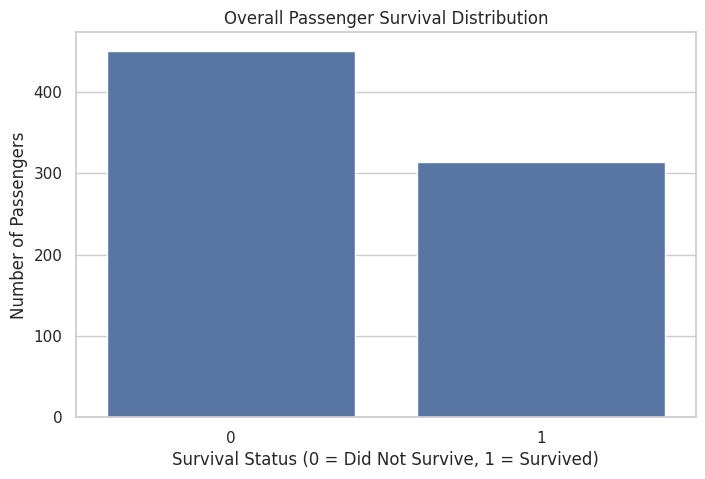

In [160]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="survived"
)

plt.title("Overall Passenger Survival Distribution")
plt.xlabel("Survival Status (0 = Did Not Survive, 1 = Survived)")
plt.ylabel("Number of Passengers")

plt.show()

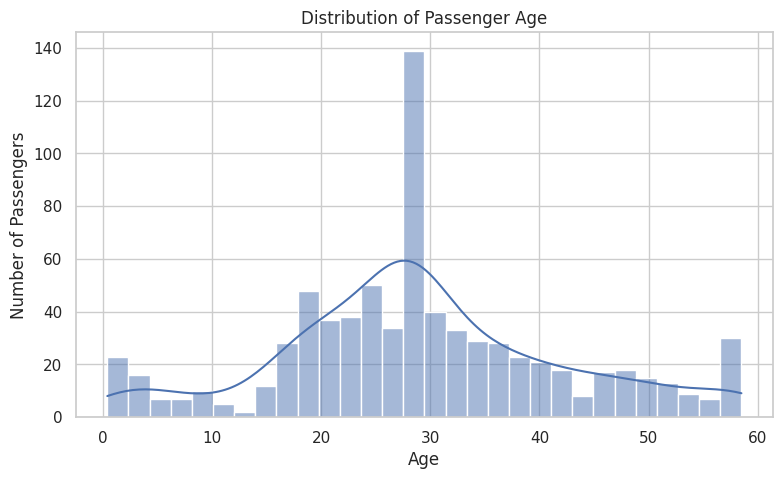

In [161]:
plt.figure(figsize=(9, 5))

sns.histplot(
    data=df,
    x="age",
    bins=30,
    kde=True
)

plt.title("Distribution of Passenger Age")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")

plt.show()

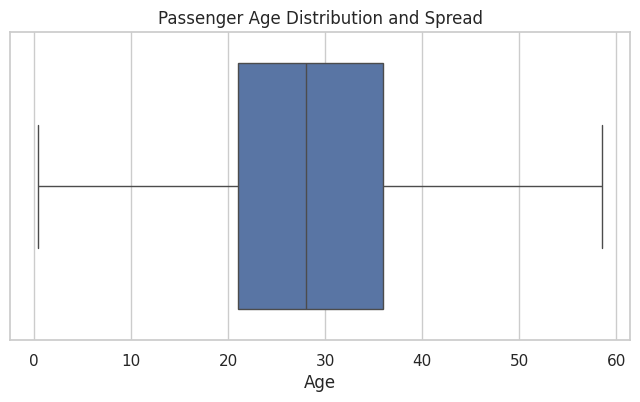

In [162]:
plt.figure(figsize=(8, 4))

sns.boxplot(
    data=df,
    x="age"
)

plt.title("Passenger Age Distribution and Spread")
plt.xlabel("Age")

plt.show()

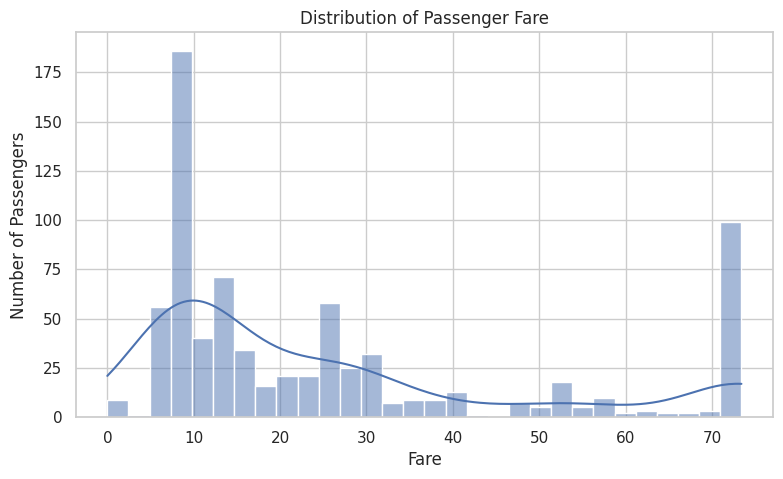

In [163]:
plt.figure(figsize=(9, 5))

sns.histplot(
    data=df,
    x="fare",
    bins=30,
    kde=True
)

plt.title("Distribution of Passenger Fare")
plt.xlabel("Fare")
plt.ylabel("Number of Passengers")

plt.show()

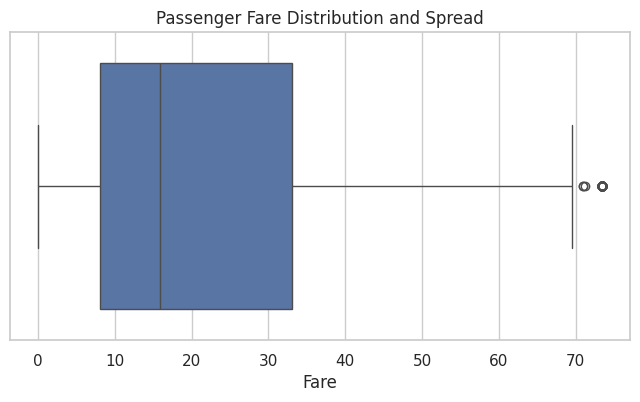

In [164]:
plt.figure(figsize=(8, 4))

sns.boxplot(
    data=df,
    x="fare"
)

plt.title("Passenger Fare Distribution and Spread")
plt.xlabel("Fare")

plt.show()

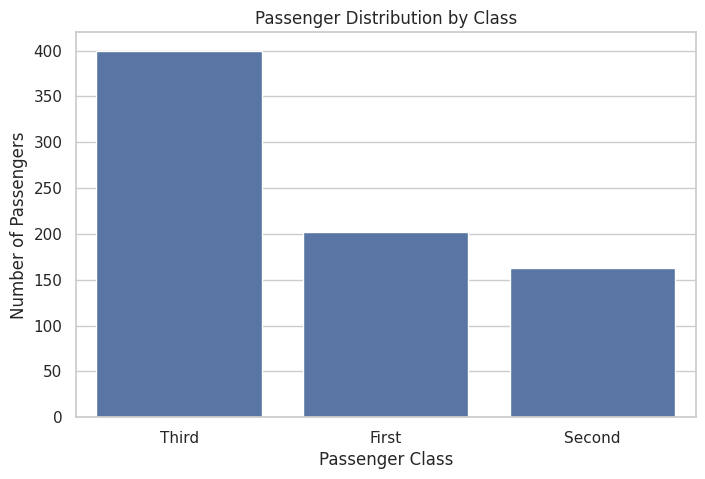

In [165]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="class",
    order=df["class"].value_counts().index
)

plt.title("Passenger Distribution by Class")
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")

plt.show()

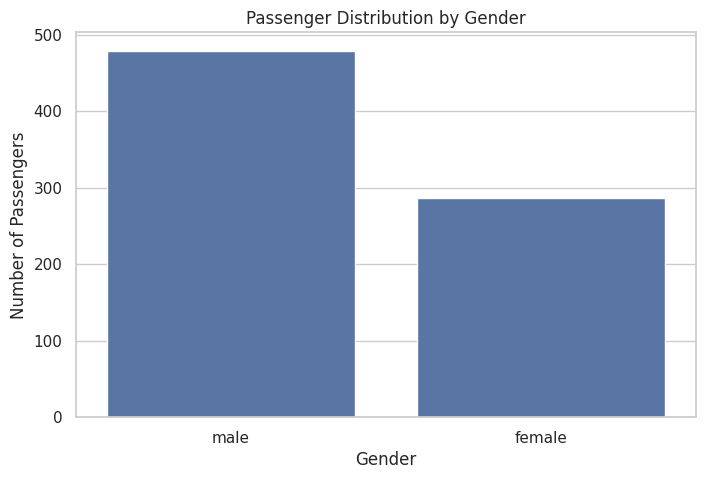

In [166]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="sex"
)

plt.title("Passenger Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Passengers")

plt.show()

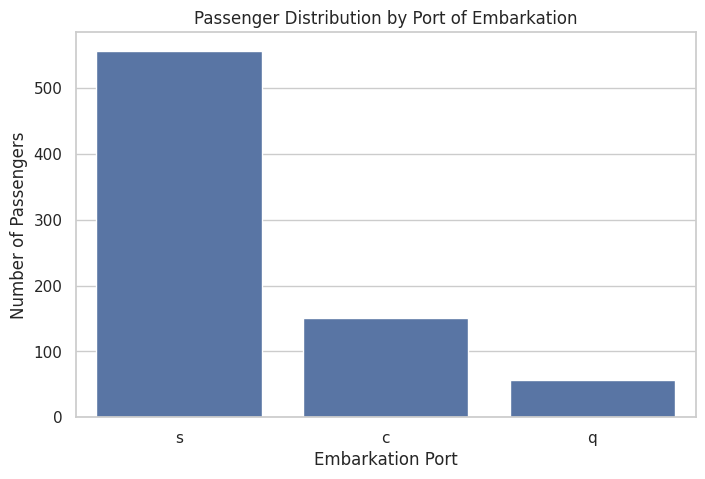

In [167]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="embarked"
)

plt.title("Passenger Distribution by Port of Embarkation")
plt.xlabel("Embarkation Port")
plt.ylabel("Number of Passengers")

plt.show()

## Bivariate Analysis

Bivariate analysis examines the relationship between two variables. In this section, survival is compared with demographic and socioeconomic characteristics such as gender, passenger class, age, and fare.

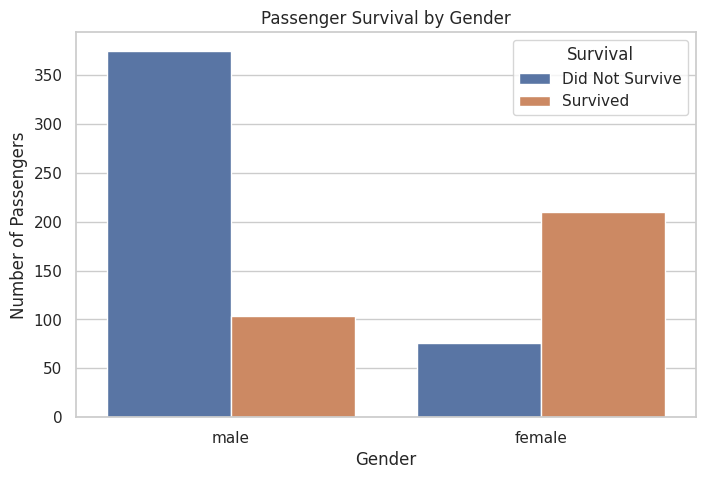

In [168]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="sex",
    hue="survived"
)

plt.title("Passenger Survival by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Passengers")
plt.legend(
    title="Survival",
    labels=["Did Not Survive", "Survived"]
)

plt.show()

In [169]:
gender_survival = (
    df.groupby("sex")["survived"]
    .mean()
    .mul(100)
    .round(2)
)

print(gender_survival)

sex
female    73.43
male      21.71
Name: survived, dtype: float64


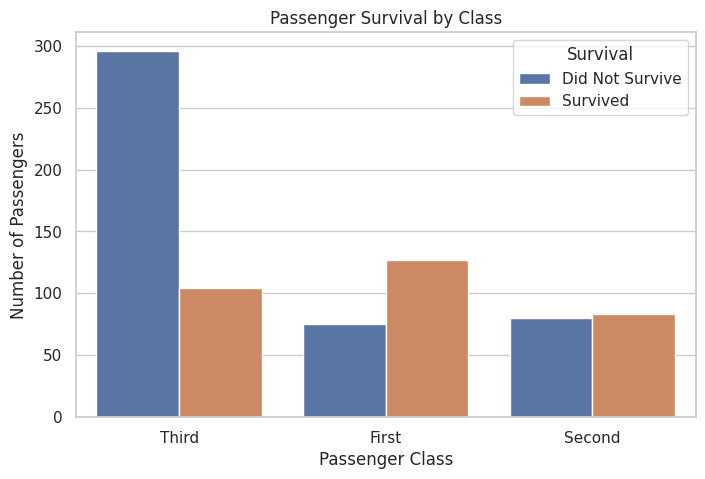

In [170]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="class",
    hue="survived"
)

plt.title("Passenger Survival by Class")
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")
plt.legend(
    title="Survival",
    labels=["Did Not Survive", "Survived"]
)

plt.show()

In [171]:
class_survival = (
    df.groupby("class")["survived"]
    .mean()
    .mul(100)
    .round(2)
)

print(class_survival)

class
First     62.87
Second    50.92
Third     26.00
Name: survived, dtype: float64


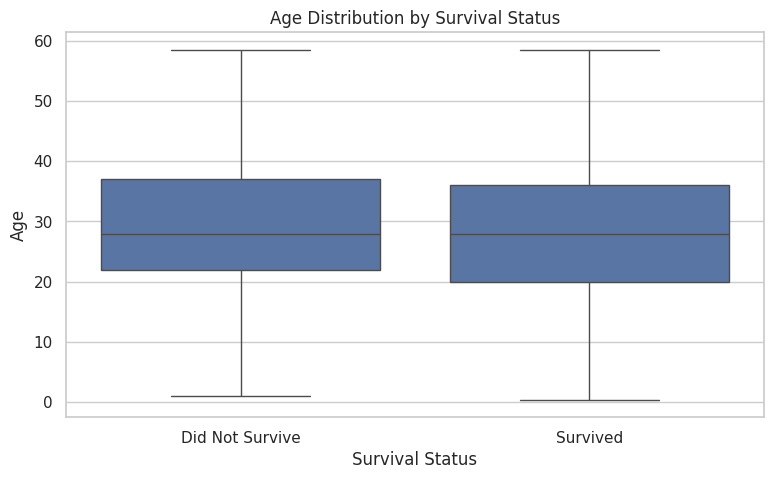

In [172]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df,
    x="survived",
    y="age"
)

plt.title("Age Distribution by Survival Status")
plt.xlabel("Survival Status")
plt.ylabel("Age")
plt.xticks(
    [0, 1],
    ["Did Not Survive", "Survived"]
)

plt.show()

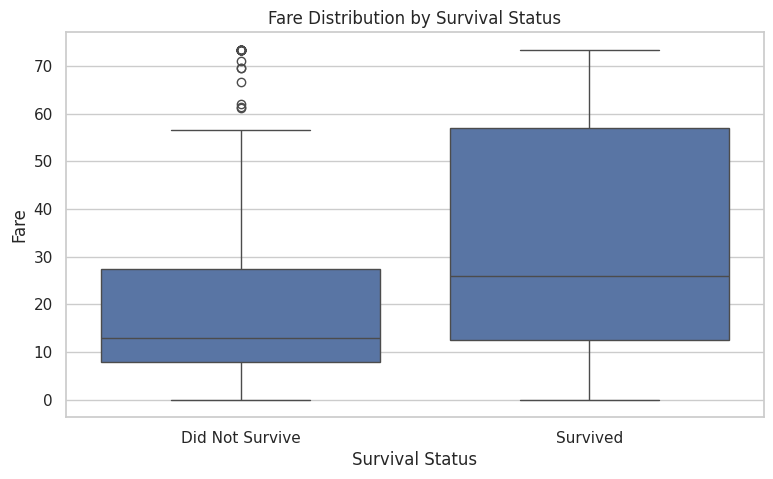

In [173]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df,
    x="survived",
    y="fare"
)

plt.title("Fare Distribution by Survival Status")
plt.xlabel("Survival Status")
plt.ylabel("Fare")
plt.xticks(
    [0, 1],
    ["Did Not Survive", "Survived"]
)

plt.show()

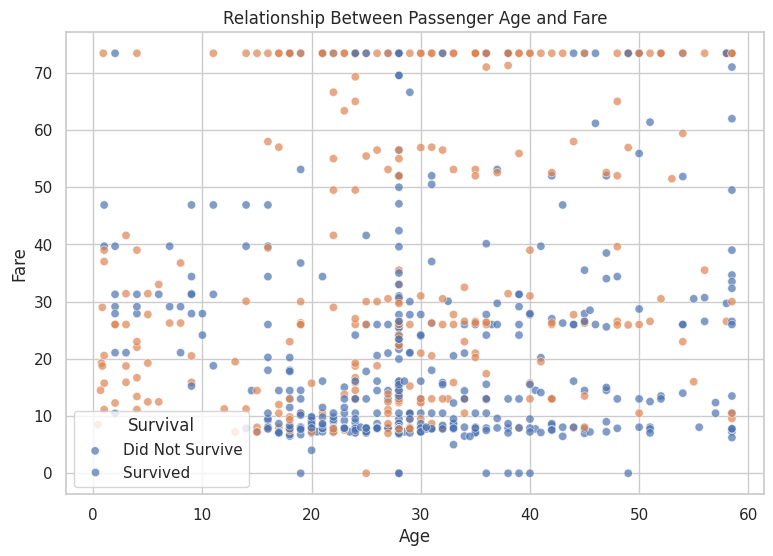

In [174]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x="age",
    y="fare",
    hue="survived",
    alpha=0.7
)

plt.title("Relationship Between Passenger Age and Fare")
plt.xlabel("Age")
plt.ylabel("Fare")
plt.legend(
    title="Survival",
    labels=["Did Not Survive", "Survived"]
)

plt.show()

In [175]:
df["family_size"] = df["sibsp"] + df["parch"] + 1

df[["sibsp", "parch", "family_size"]].head()

,sibsp,parch,family_size
0,1,0,2
1,1,0,2
2,0,0,1
3,1,0,2
4,0,0,1


### Family Size Transformation

A new `family_size` variable was created by combining the number of siblings/spouses (`sibsp`) and parents/children (`parch`) and adding one for the passenger themselves.

This transformation provides a more interpretable measure of the total travelling family size.

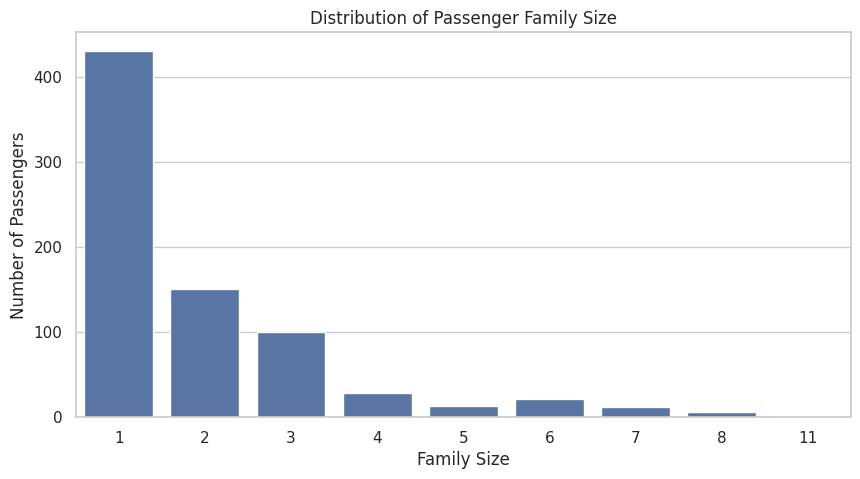

In [176]:
plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    x="family_size"
)

plt.title("Distribution of Passenger Family Size")
plt.xlabel("Family Size")
plt.ylabel("Number of Passengers")

plt.show()

In [177]:
family_survival = (
    df.groupby("family_size")["survived"]
    .mean()
    .mul(100)
    .round(2)
)

print(family_survival)

family_size
1     33.64
2     54.30
3     57.00
4     71.43
5     23.08
6     13.64
7     33.33
8      0.00
11     0.00
Name: survived, dtype: float64


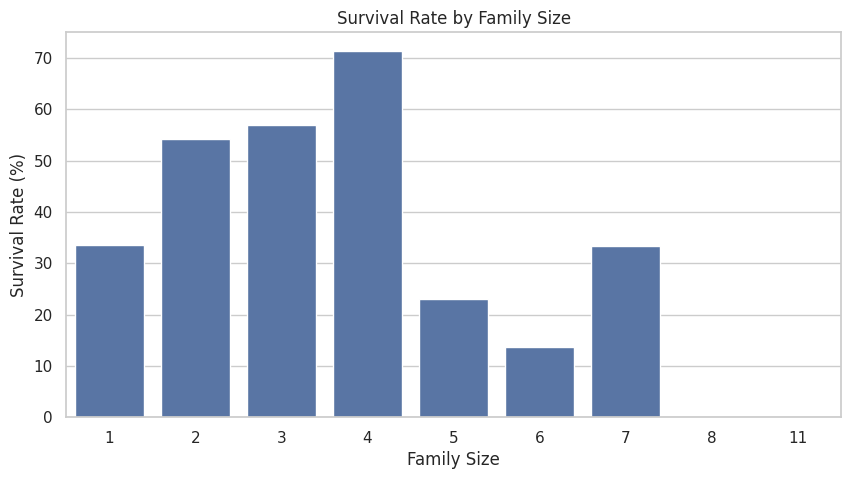

In [178]:
plt.figure(figsize=(10, 5))

sns.barplot(
    x=family_survival.index,
    y=family_survival.values
)

plt.title("Survival Rate by Family Size")
plt.xlabel("Family Size")
plt.ylabel("Survival Rate (%)")

plt.show()

## Multivariate Analysis

Multivariate analysis examines relationships among multiple variables simultaneously. This section investigates how demographic and socioeconomic characteristics interact with passenger survival.

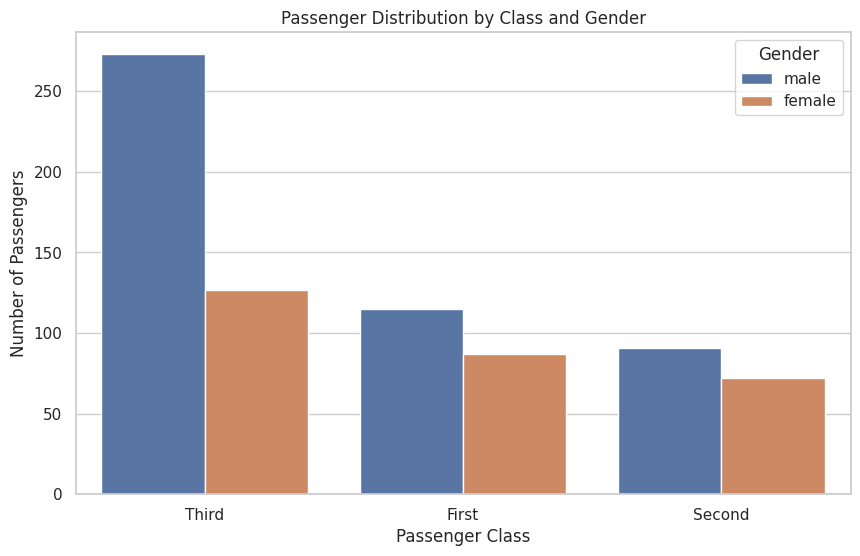

In [179]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    x="class",
    hue="sex",
    palette=None
)

plt.title("Passenger Distribution by Class and Gender")
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")

plt.legend(title="Gender")

plt.show()

In [180]:
class_gender_survival = (
    df.groupby(["class", "sex"])["survived"]
    .mean()
    .mul(100)
    .round(2)
)

class_gender_survival

class   sex   
First   female    96.55
        male      37.39
Second  female    91.67
        male      18.68
Third   female    47.24
        male      16.12
Name: survived, dtype: float64

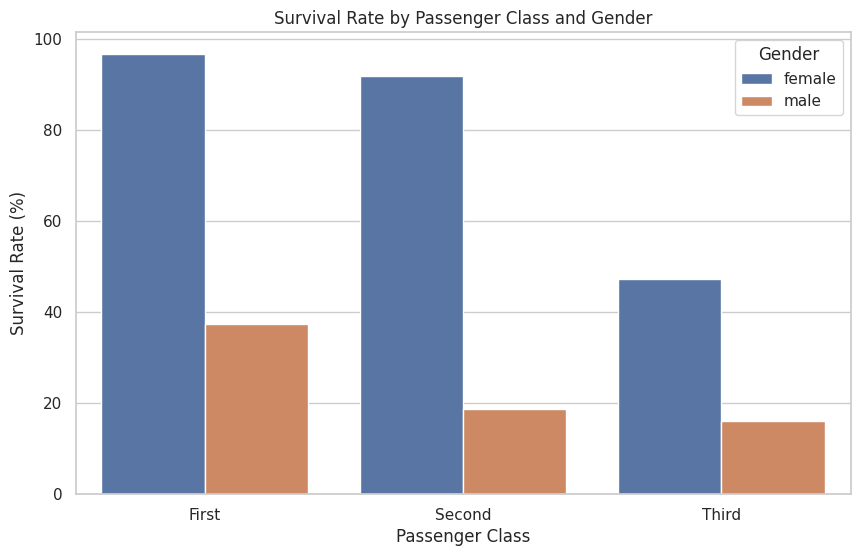

In [181]:
plot_data = class_gender_survival.reset_index()

plt.figure(figsize=(10, 6))

sns.barplot(
    data=plot_data,
    x="class",
    y="survived",
    hue="sex"
)

plt.title("Survival Rate by Passenger Class and Gender")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate (%)")
plt.legend(title="Gender")

plt.show()

In [182]:
bins = [0, 12, 18, 30, 50, 65, 100]

labels = [
    "Child",
    "Teenager",
    "Young Adult",
    "Adult",
    "Senior Adult",
    "Senior"
]

df["age_group"] = pd.cut(
    df["age"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

df[["age", "age_group"]].head(10)

,age,age_group
0,22.0,Young Adult
1,38.0,Adult
2,26.0,Young Adult
3,35.0,Adult
4,35.0,Adult
5,28.0,Young Adult
6,54.0,Senior Adult
7,2.0,Child
8,27.0,Young Adult
9,14.0,Teenager


In [183]:
age_group_survival = (
    df.groupby("age_group", observed=True)["survived"]
    .mean()
    .mul(100)
    .round(2)
)

age_group_survival

,survived
age_group,
Child,57.35
Teenager,44.78
Young Adult,36.84
Adult,42.36
Senior Adult,37.29


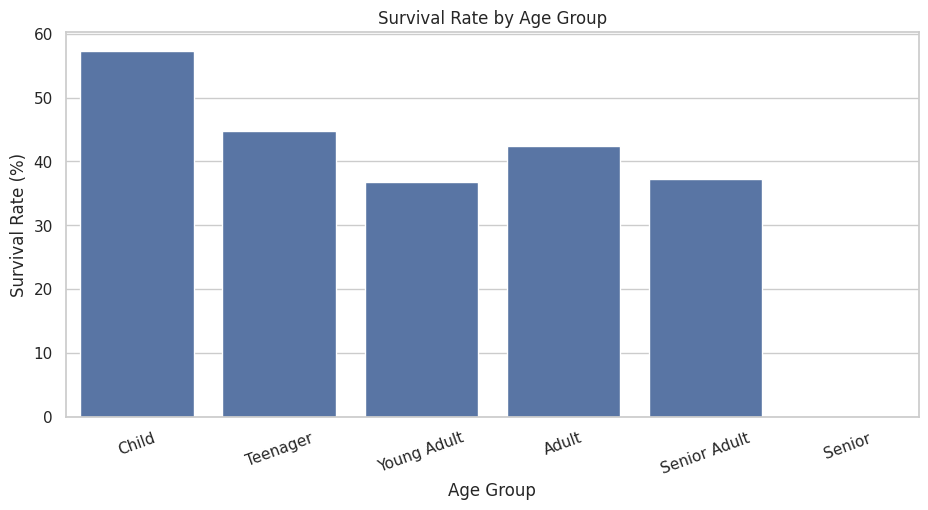

In [184]:
plt.figure(figsize=(11, 5))

sns.barplot(
    x=age_group_survival.index,
    y=age_group_survival.values
)

plt.title("Survival Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Survival Rate (%)")

plt.xticks(rotation=20)

plt.show()

In [185]:
numeric_columns = df.select_dtypes(
    include=np.number
).columns

numeric_columns

Index(['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare', 'family_size'], dtype='object')

In [186]:
correlation_matrix = df[numeric_columns].corr()

correlation_matrix

,survived,pclass,age,sibsp,parch,fare,family_size
survived,1.000000,-0.326559,-0.068880,-0.041808,0.071161,0.293172,0.012088
pclass,-0.326559,1.000000,-0.345391,0.088177,0.034467,-0.738462,0.076374
age,-0.068880,-0.345391,1.000000,-0.283517,-0.184641,0.153708,-0.286313
sibsp,-0.041808,0.088177,-0.283517,1.000000,0.379268,0.264851,0.859733
parch,0.071161,0.034467,-0.184641,0.379268,1.000000,0.247493,0.798653
fare,0.293172,-0.738462,0.153708,0.264851,0.247493,1.000000,0.308867
family_size,0.012088,0.076374,-0.286313,0.859733,0.798653,0.308867,1.000000


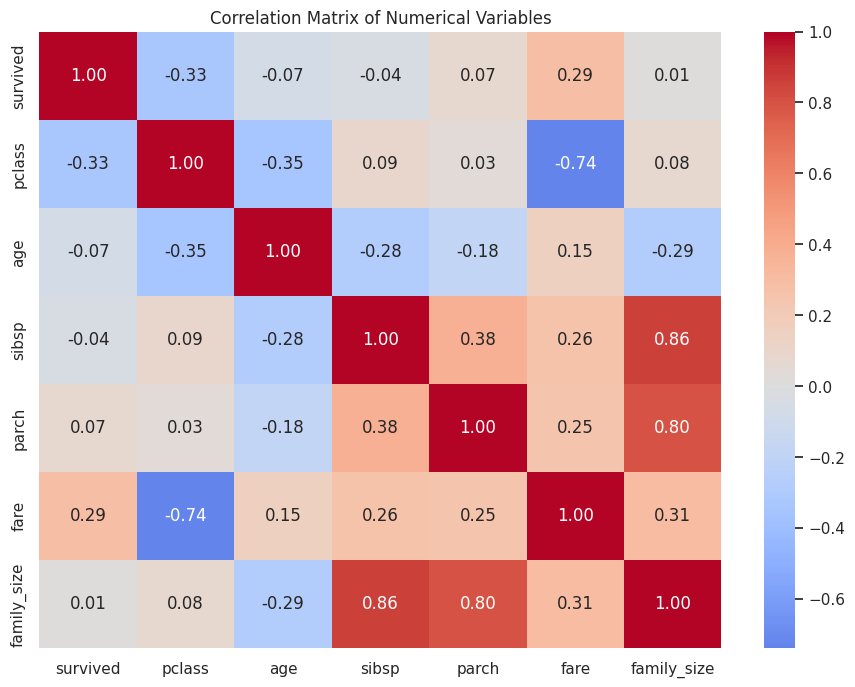

In [187]:
plt.figure(figsize=(11, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Numerical Variables")

plt.show()

In [188]:
pivot_survival = pd.pivot_table(
    df,
    values="survived",
    index="class",
    columns="sex",
    aggfunc="mean"
) * 100

pivot_survival.round(2)

sex,female,male
class,,
First,96.55,37.39
Second,91.67,18.68
Third,47.24,16.12


In [189]:
embarked_survival = (
    df.groupby("embarked")["survived"]
    .mean()
    .mul(100)
    .round(2)
)

embarked_survival

,survived
embarked,
c,56.95
q,35.09
s,37.34


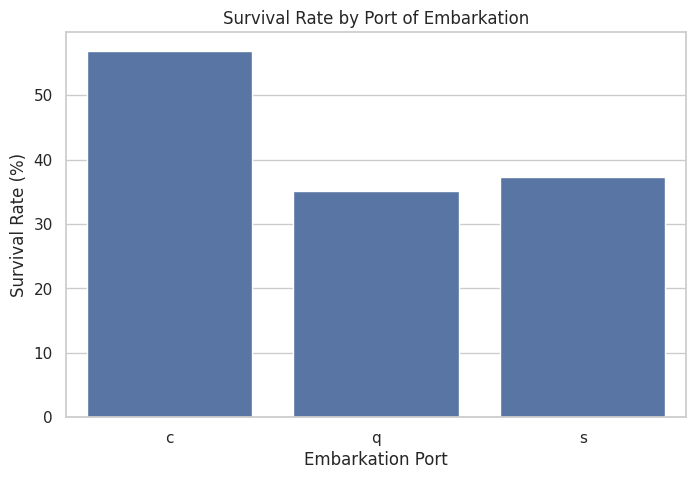

In [190]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=embarked_survival.index,
    y=embarked_survival.values
)

plt.title("Survival Rate by Port of Embarkation")
plt.xlabel("Embarkation Port")
plt.ylabel("Survival Rate (%)")

plt.show()

In [191]:
sibsp_survival = (
    df.groupby("sibsp")["survived"]
    .mean()
    .mul(100)
    .round(2)
)

sibsp_survival

,survived
sibsp,
0,38.25
1,52.28
2,44.44
3,28.57
4,16.67
5,0.00
8,0.00


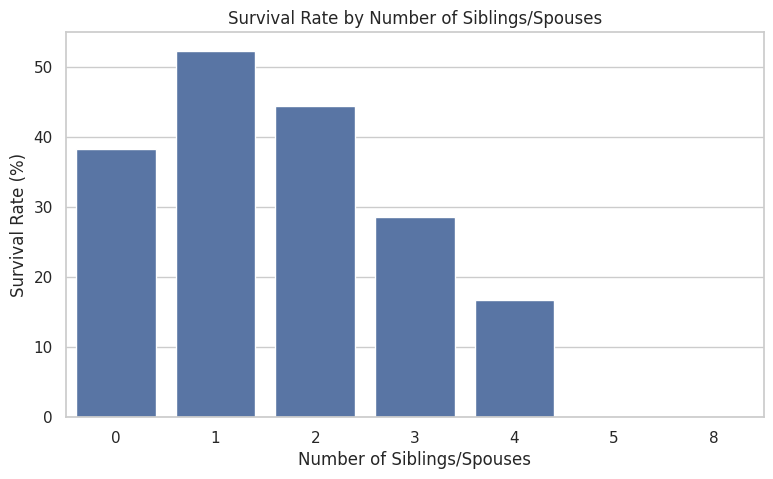

In [192]:
plt.figure(figsize=(9, 5))

sns.barplot(
    x=sibsp_survival.index,
    y=sibsp_survival.values
)

plt.title("Survival Rate by Number of Siblings/Spouses")
plt.xlabel("Number of Siblings/Spouses")
plt.ylabel("Survival Rate (%)")

plt.show()

In [193]:
parch_survival = (
    df.groupby("parch")["survived"]
    .mean()
    .mul(100)
    .round(2)
)

parch_survival

,survived
parch,
0,37.01
1,54.87
2,53.33
3,60.00
4,0.00
5,20.00
6,0.00


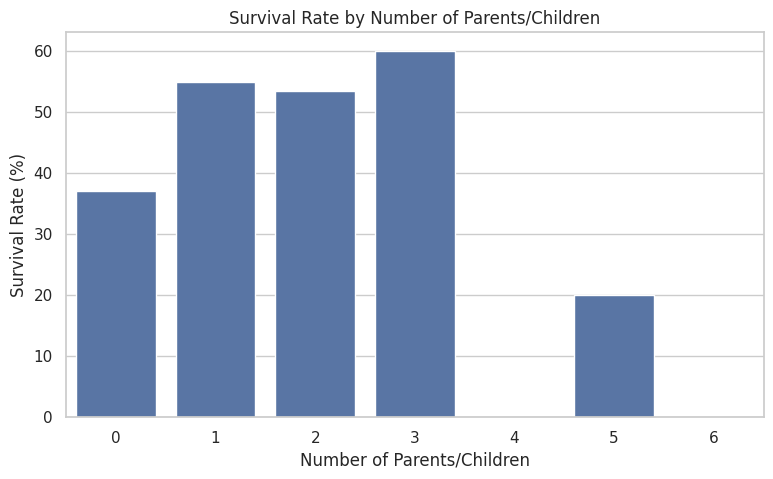

In [194]:
plt.figure(figsize=(9, 5))

sns.barplot(
    x=parch_survival.index,
    y=parch_survival.values
)

plt.title("Survival Rate by Number of Parents/Children")
plt.xlabel("Number of Parents/Children")
plt.ylabel("Survival Rate (%)")

plt.show()

In [195]:
Q1 = df["fare"].quantile(0.25)
Q3 = df["fare"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

fare_anomalies = df[
    (df["fare"] < lower_bound) |
    (df["fare"] > upper_bound)
]

print("Potential fare anomalies:", len(fare_anomalies))

fare_anomalies[["age", "sex", "class", "fare", "survived"]].head(20)

Potential fare anomalies: 99


,age,sex,class,fare,survived
1,38.0,female,First,71.28330,1
27,19.0,male,First,73.41975,0
31,28.0,female,First,73.41975,1
34,28.0,male,First,73.41975,0
51,49.0,female,First,73.41975,1
59,38.0,female,First,73.41975,1
60,45.0,male,First,73.41975,0
70,21.0,male,Second,73.41975,0
83,23.0,female,First,73.41975,1
95,21.0,male,First,73.41975,0


In [196]:
Q1_age = df["age"].quantile(0.25)
Q3_age = df["age"].quantile(0.75)

IQR_age = Q3_age - Q1_age

lower_age = Q1_age - 1.5 * IQR_age
upper_age = Q3_age + 1.5 * IQR_age

age_anomalies = df[
    (df["age"] < lower_age) |
    (df["age"] > upper_age)
]

print("Potential age anomalies:", len(age_anomalies))

Potential age anomalies: 0


In [197]:
summary = {
    "Total Passengers": len(df),
    "Survivors": int(df["survived"].sum()),
    "Overall Survival Rate (%)": round(df["survived"].mean() * 100, 2),
    "Average Age": round(df["age"].mean(), 2),
    "Median Age": round(df["age"].median(), 2),
    "Average Fare": round(df["fare"].mean(), 2),
    "Median Fare": round(df["fare"].median(), 2)
}

summary_df = pd.DataFrame(
    summary.items(),
    columns=["Metric", "Value"]
)

summary_df

,Metric,Value
0,Total Passengers,765.00
1,Survivors,314.00
2,Overall Survival Rate (%),41.05
3,Average Age,29.20
4,Median Age,28.00
5,Average Fare,26.27
6,Median Fare,15.85


In [198]:
highest_gender = gender_survival.idxmax()
highest_gender_rate = gender_survival.max()

highest_class = class_survival.idxmax()
highest_class_rate = class_survival.max()

highest_age_group = age_group_survival.idxmax()
highest_age_group_rate = age_group_survival.max()

highest_family_size = family_survival.idxmax()
highest_family_rate = family_survival.max()

print("KEY FINDINGS")
print("-" * 50)

print(
    f"Overall survival rate: "
    f"{df['survived'].mean() * 100:.2f}%"
)

print(
    f"Highest survival rate by gender: "
    f"{highest_gender} ({highest_gender_rate:.2f}%)"
)

print(
    f"Highest survival rate by passenger class: "
    f"{highest_class} ({highest_class_rate:.2f}%)"
)

print(
    f"Highest survival rate by age group: "
    f"{highest_age_group} ({highest_age_group_rate:.2f}%)"
)

print(
    f"Family size with highest observed survival rate: "
    f"{highest_family_size} ({highest_family_rate:.2f}%)"
)

KEY FINDINGS
--------------------------------------------------
Overall survival rate: 41.05%
Highest survival rate by gender: female (73.43%)
Highest survival rate by passenger class: First (62.87%)
Highest survival rate by age group: Child (57.35%)
Family size with highest observed survival rate: 4 (71.43%)


In [199]:
# Handle remaining missing values in embark_town
df["embark_town"] = df["embark_town"].fillna(
    df["embark_town"].mode()[0]
)

print("Remaining missing values in embark_town:",
      df["embark_town"].isnull().sum())

Remaining missing values in embark_town: 0


In [200]:
print("Final dataset shape:", df.shape)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

print("\nColumns:")
print(df.columns.tolist())

Final dataset shape: (765, 16)

Missing values:
survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
family_size    0
age_group      0
dtype: int64

Duplicate rows:
0

Columns:
['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'embark_town', 'alive', 'alone', 'family_size', 'age_group']


In [203]:
df.to_csv(
    "titanic_eda.csv",
    index=False
)

print("titanic_eda.csv saved successfully.")

titanic_eda.csv saved successfully.


# Conclusion

The exploratory data analysis provided a detailed understanding of the Titanic dataset through statistical analysis, transformations, aggregations, and visualization.

The analysis examined individual variable distributions as well as relationships between passenger survival and factors such as gender, passenger class, age, fare, family size, and embarkation port.

Multiple visualizations were used to identify patterns, relationships, and potential anomalies. The analysis also demonstrated how transformations such as family-size calculation and age-group categorization can create more meaningful variables for analysis.

The correlation analysis helped identify relationships among numerical variables, while grouped analysis and pivot tables provided deeper comparisons between categorical variables and survival outcomes.

Overall, the EDA demonstrates that passenger characteristics were associated with different survival patterns. These findings provide a useful foundation for subsequent statistical analysis and machine-learning tasks.